In [19]:
from sklearn.neural_network import MLPClassifier
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [20]:
df = pd.read_csv("../data/train_clear.csv")

In [21]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [22]:
X_encoded = pd.get_dummies(X, drop_first=True).astype(int)

In [23]:
X_scaled = StandardScaler().fit_transform(X_encoded)

In [24]:
le = LabelEncoder()
y_encoded = np.array(le.fit_transform(y))

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
feature_importance = []

In [26]:
def train_model(model, X, y):
    all_y_true = []
    all_y_pred = []
    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        
        score = model.score(X_val, y_val)
        cv_scores.append(score)

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

    scores = np.array(cv_scores)
    print(f"Точность {model.__class__.__name__}: {scores.mean():0.3f} ± {scores.std():0.3f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    disp_raw = ConfusionMatrixDisplay.from_predictions(
        all_y_true, 
        all_y_pred, 
        display_labels=le.classes_,
        ax=ax,
        normalize="true"
    )
    plt.xticks(rotation=45, ha='right')

c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum itera

Точность MLPClassifier: 0.793 ± 0.004


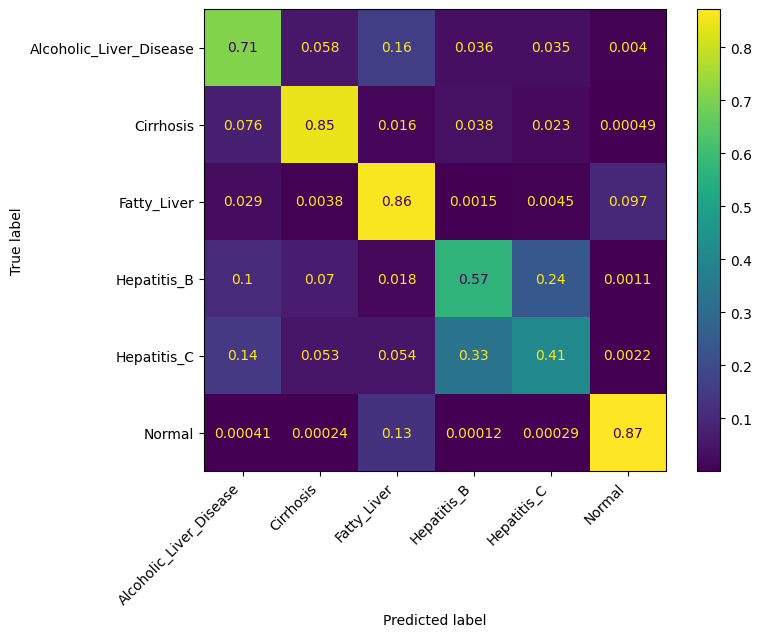

In [27]:
model = MLPClassifier()
train_model(model, X_scaled, y_encoded)

Точность MLPClassifier: 0.798 ± 0.007


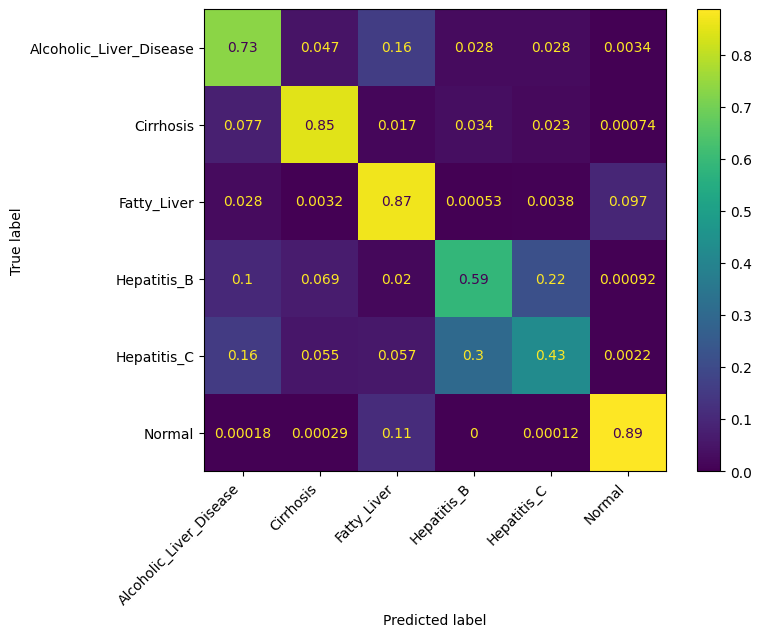

In [ ]:
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    batch_size="auto",
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
train_model(model, X_scaled, y_encoded)